Sentiment columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='str')
Trades columns: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='str')
Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values (Sentiment):
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trades):
 account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
dtype: int64

Merged Data Sample:
          date   daily_pnl  win_rate  avg_trade_

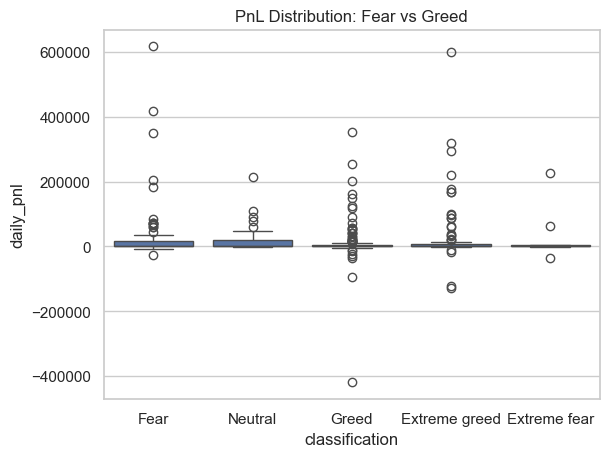

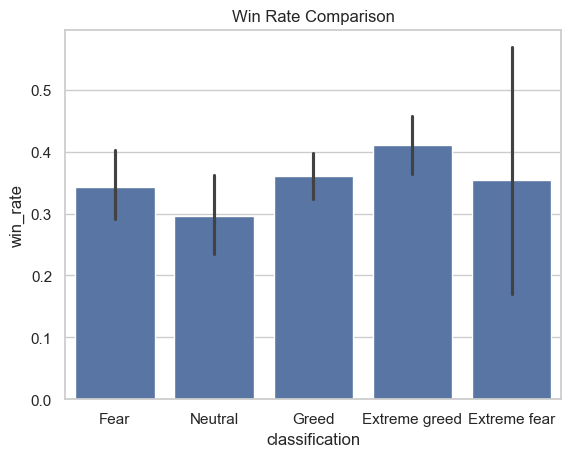

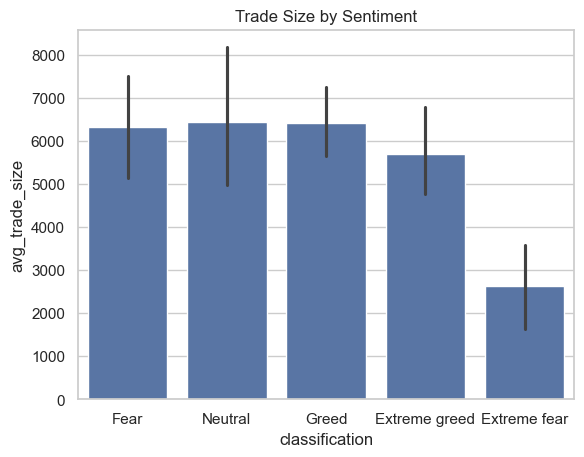


Segment Analysis (Trade Size):
 size_group              High           Low
classification                            
Extreme fear    -2365.961276  32387.237773
Extreme greed    1494.610591  38815.808507
Fear            50739.043342  15660.859094
Greed              95.443617  19987.436858
Neutral         11578.693249  22158.573075

Segment Analysis (Trader Type):
 trader_type         Frequent   Infrequent
classification                           
Extreme fear    51198.905975   184.352758
Extreme greed   43909.798085  1049.887796
Fear            60098.797614   887.609359
Greed           17904.351743  1502.576006
Neutral         31154.018954  1930.736512

--- Key Insights ---
1. Avg PnL during Fear: 33865.99
   Avg PnL during Greed: 9099.19
→ Traders perform better during Fear periods.

2. High trade size PnL: 11236.82
   Low trade size PnL: 25259.04

3. Frequent traders PnL: 35270.75
   Infrequent traders PnL: 1331.92


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---------------------------
# LOAD DATA
# ---------------------------
sentiment = pd.read_csv("C:/Users/BSES/Downloads/fear_greed_index.csv")
trades = pd.read_csv("C:/Users/BSES/Downloads/historical_data.csv")

# ---------------------------
# CLEAN COLUMN NAMES
# ---------------------------
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

print("Sentiment columns:", sentiment.columns)
print("Trades columns:", trades.columns)

# ---------------------------
# BASIC INFO
# ---------------------------
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values (Sentiment):\n", sentiment.isnull().sum())
print("\nMissing values (Trades):\n", trades.isnull().sum())

# Remove duplicates
sentiment.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)

# ---------------------------
# DATE HANDLING (FINAL FIX)
# ---------------------------
# Handle mixed formats safely
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Drop invalid dates if any
sentiment = sentiment.dropna(subset=['date'])

# Convert trades timestamp (Indian format)
trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    dayfirst=True,
    errors='coerce'
)

trades = trades.dropna(subset=['timestamp ist'])

# Convert to daily level
trades['date'] = trades['timestamp ist'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# ---------------------------
# FEATURE ENGINEERING
# ---------------------------
trades['win'] = trades['closed pnl'].apply(lambda x: 1 if x > 0 else 0)

daily_metrics = trades.groupby('date').agg({
    'closed pnl': 'sum',
    'win': 'mean',
    'size usd': 'mean',
    'account': 'count'
}).reset_index()

daily_metrics.rename(columns={
    'closed pnl': 'daily_pnl',
    'win': 'win_rate',
    'size usd': 'avg_trade_size',
    'account': 'num_trades'
}, inplace=True)

# ---------------------------
# LONG vs SHORT RATIO
# ---------------------------
long_short = trades.groupby(['date', 'side']).size().unstack(fill_value=0)
long_short.columns = long_short.columns.str.lower()

long_short['long_short_ratio'] = long_short.get('long', 0) / (long_short.get('short', 1))
long_short = long_short.reset_index()

daily_metrics = daily_metrics.merge(
    long_short[['date', 'long_short_ratio']],
    on='date',
    how='left'
)

# ---------------------------
# MERGE DATASETS
# ---------------------------
merged = daily_metrics.merge(sentiment, on='date', how='inner')

# Clean classification
merged['classification'] = merged['classification'].str.capitalize()

print("\nMerged Data Sample:\n", merged.head())

# ---------------------------
# ANALYSIS
# ---------------------------
grouped = merged.groupby('classification').agg({
    'daily_pnl': 'mean',
    'win_rate': 'mean',
    'avg_trade_size': 'mean',
    'num_trades': 'mean'
})

print("\nFear vs Greed Summary:\n", grouped)

# ---------------------------
# VISUALIZATION
# ---------------------------
sns.boxplot(x='classification', y='daily_pnl', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

sns.barplot(x='classification', y='win_rate', data=merged)
plt.title("Win Rate Comparison")
plt.show()

sns.barplot(x='classification', y='avg_trade_size', data=merged)
plt.title("Trade Size by Sentiment")
plt.show()

# ---------------------------
# SEGMENTATION
# ---------------------------
threshold = merged['avg_trade_size'].median()

merged['size_group'] = merged['avg_trade_size'].apply(
    lambda x: 'High' if x > threshold else 'Low'
)

seg_analysis = merged.groupby(['classification', 'size_group'])['daily_pnl'].mean().unstack()
print("\nSegment Analysis (Trade Size):\n", seg_analysis)

freq_threshold = merged['num_trades'].median()

merged['trader_type'] = merged['num_trades'].apply(
    lambda x: 'Frequent' if x > freq_threshold else 'Infrequent'
)

freq_analysis = merged.groupby(['classification', 'trader_type'])['daily_pnl'].mean().unstack()
print("\nSegment Analysis (Trader Type):\n", freq_analysis)

# ---------------------------
# FINAL INSIGHTS
# ---------------------------
print("\n--- Key Insights ---")

fear = merged[merged['classification'] == 'Fear']['daily_pnl'].mean()
greed = merged[merged['classification'] == 'Greed']['daily_pnl'].mean()

print(f"1. Avg PnL during Fear: {fear:.2f}")
print(f"   Avg PnL during Greed: {greed:.2f}")

if fear < greed:
    print("→ Traders perform better during Greed periods.")
else:
    print("→ Traders perform better during Fear periods.")

size_high = merged[merged['size_group'] == 'High']['daily_pnl'].mean()
size_low = merged[merged['size_group'] == 'Low']['daily_pnl'].mean()

print(f"\n2. High trade size PnL: {size_high:.2f}")
print(f"   Low trade size PnL: {size_low:.2f}")

freq_high = merged[merged['trader_type'] == 'Frequent']['daily_pnl'].mean()
freq_low = merged[merged['trader_type'] == 'Infrequent']['daily_pnl'].mean()

print(f"\n3. Frequent traders PnL: {freq_high:.2f}")
print(f"   Infrequent traders PnL: {freq_low:.2f}")